K Means Clustering - 3D

In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

In [2]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import preprocessing
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd
import phate
import math
import random
import gc
import scprep
from datetime import datetime, time
from matplotlib.animation import ImageMagickWriter
import matplotlib.animation as animation
import zipfile
from urllib.request import urlopen
import scipy.stats as st
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.stats import kde
from scipy.stats import binned_statistic
from scipy.stats import f_oneway
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['pdf.fonttype'] = 42
print(sns.__version__)
from anndata import AnnData
import scanpy as sc
from delve import *
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
from kh import sketch
from sklearn.cluster import KMeans
import umap
print(sc.__version__)
today = datetime.now().strftime("%m%d%Y-%H%M")

0.11.2
1.9.1


In [3]:
#Save the entire adata file with new PHATE embeddings
adata_save_path = os.path.join(base_dir, 'standard_adata_sub__control_abema_PHATE_kmeans_assigned.h5ad')
standard_adata_sub = anndata.read_h5ad(adata_save_path)

In [ ]:
standard_adata_sub.obs

,label,well,sample_ID,treatment,dose,centroid-0,centroid-1,kmeans_clusters_k4,kmeans_clusters_k5,kmeans_clusters_k6,kmeans_clusters_k7,kmeans_clusters_k8,kmeans_clusters_k9,kmeans_clusters_k10,kmeans_clusters_k11,kmeans_clusters_k12
c_8195,8246,B02,1,Control,0,5469.757700,4824.316222,1,3,3,0,3,3,5,8,0
c_8202,8253,B02,1,Control,0,5483.343866,6206.133829,0,2,3,0,1,8,9,8,0
c_95781,6556,C02,1,Control,0,3888.575526,5080.470363,2,0,4,1,0,2,6,5,1
c_8215,8266,B02,1,Control,0,5487.934186,4472.990859,1,3,0,5,3,4,1,3,4
c_8216,8267,B02,1,Control,0,5485.820248,4731.588843,0,2,3,0,1,8,9,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_65819,8210,B08,7,Abema,500 nM,5946.179104,2972.264925,0,2,3,4,5,1,3,9,3
c_65826,8217,B08,7,Abema,500 nM,5951.076471,6279.390196,0,2,3,4,5,0,8,9,3
c_157565,6954,C08,7,Abema,500 nM,4704.976945,1487.031700,1,3,3,4,3,3,5,6,10
c_65835,8226,B08,7,Abema,500 nM,5956.075893,3223.502232,0,2,3,4,5,1,3,9,3


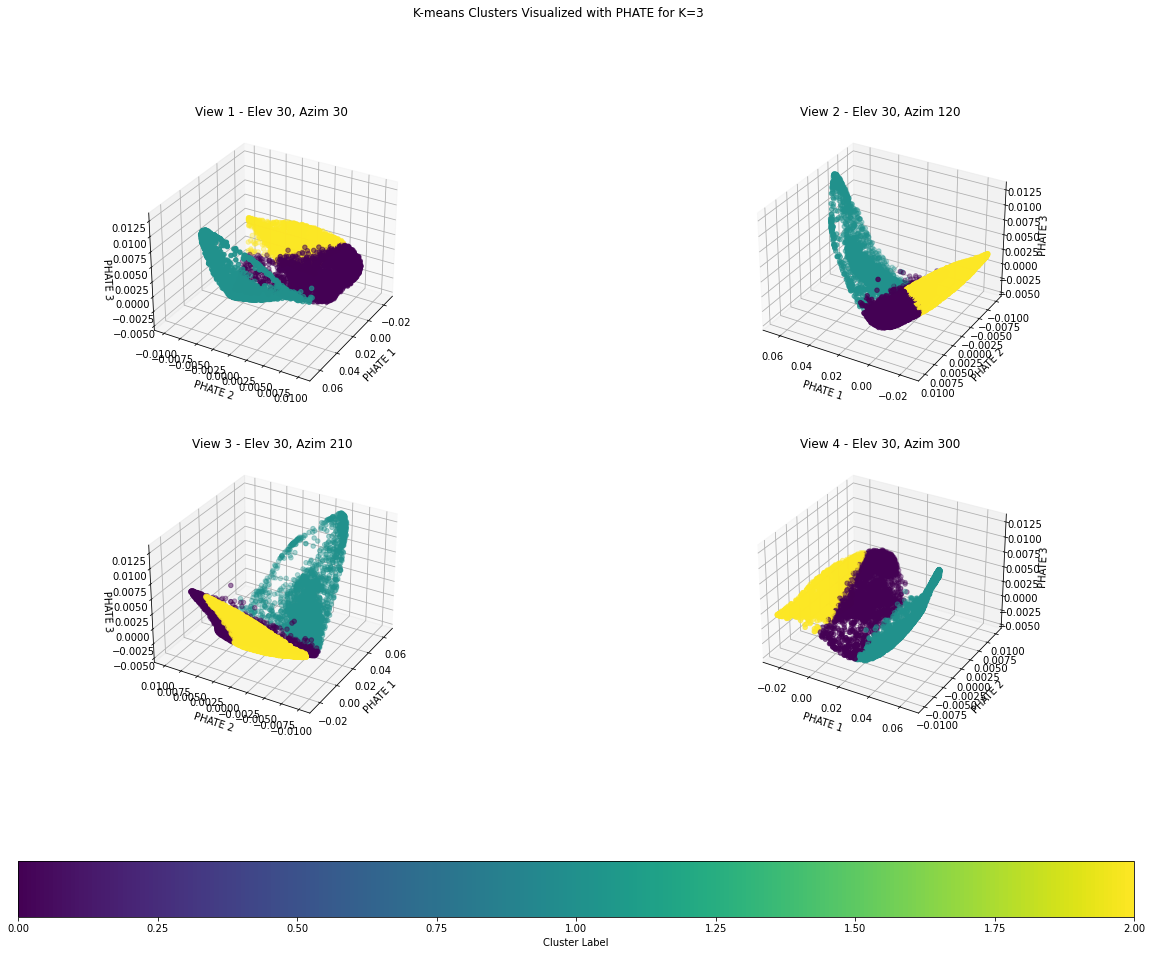

Cluster 0 for K=3 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    603
5    564
1    525
4    518
3    512
2    511
7    476
Name: sample_ID, dtype: int64

Cluster 1 for K=3 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    647
2    548
3    422
4    320
7    118
5     90
6     78
Name: sample_ID, dtype: int64

Cluster 2 for K=3 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    906
5    846
6    819
4    662
3    566
2    441
1    328
Name: sample_ID, dtype: int64



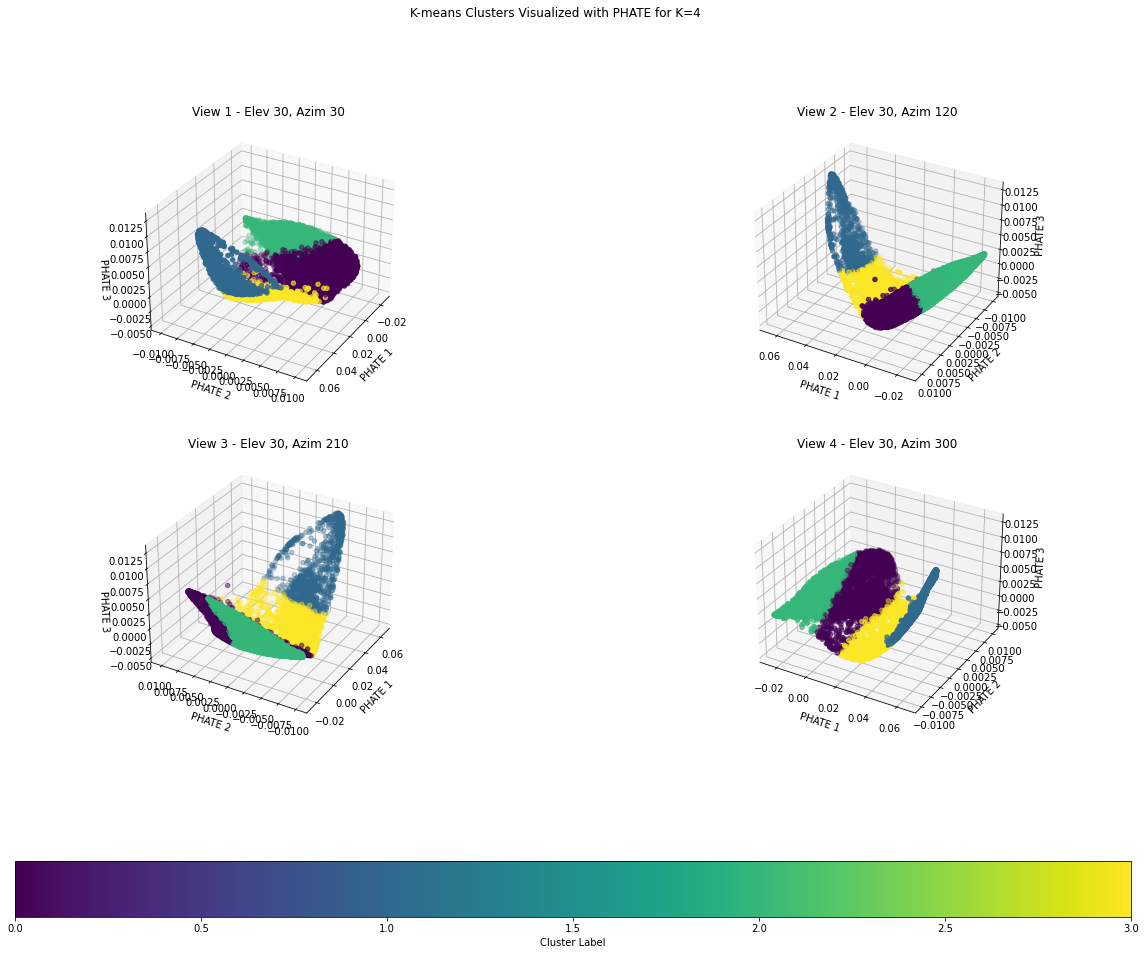

Cluster 0 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    662
5    633
4    552
3    546
7    529
2    511
1    504
Name: sample_ID, dtype: int64

Cluster 1 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    295
2    235
3    177
4    130
7     89
6     62
5     55
Name: sample_ID, dtype: int64

Cluster 2 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    840
5    763
6    740
4    603
3    499
2    377
1    284
Name: sample_ID, dtype: int64

Cluster 3 for K=4 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    417
2    377
3    278
4    215
5     49
7     42
6     36
Name: sample_ID, dtype: int64



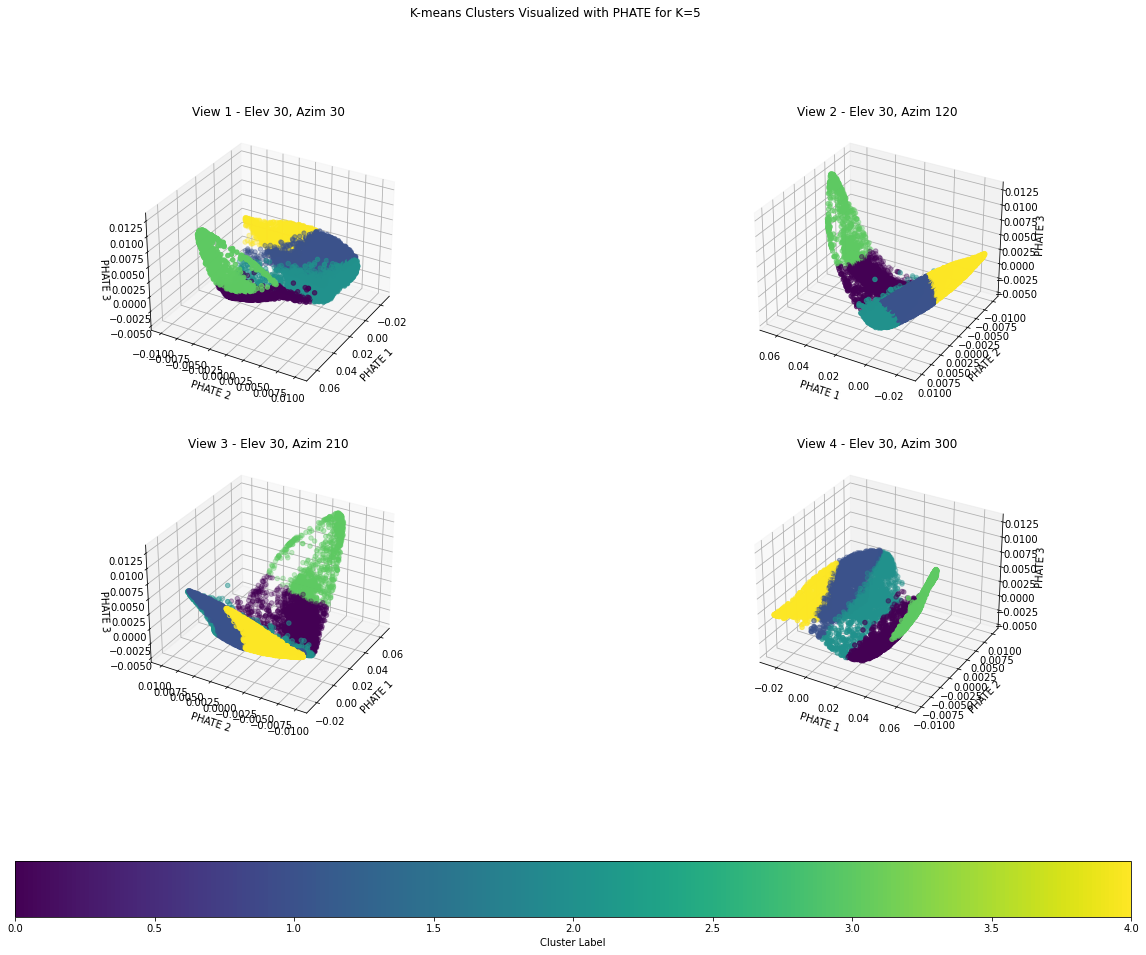

Cluster 0 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    454
2    395
3    300
4    234
5     44
7     33
6     21
Name: sample_ID, dtype: int64

Cluster 1 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    580
6    566
4    517
7    477
3    465
2    433
1    365
Name: sample_ID, dtype: int64

Cluster 2 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    338
5    303
1    279
7    271
2    270
3    269
4    263
Name: sample_ID, dtype: int64

Cluster 3 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    215
2    179
3    138
4     98
7     89
6     61
5     49
Name: sample_ID, dtype: int64

Cluster 4 for K=5 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7   

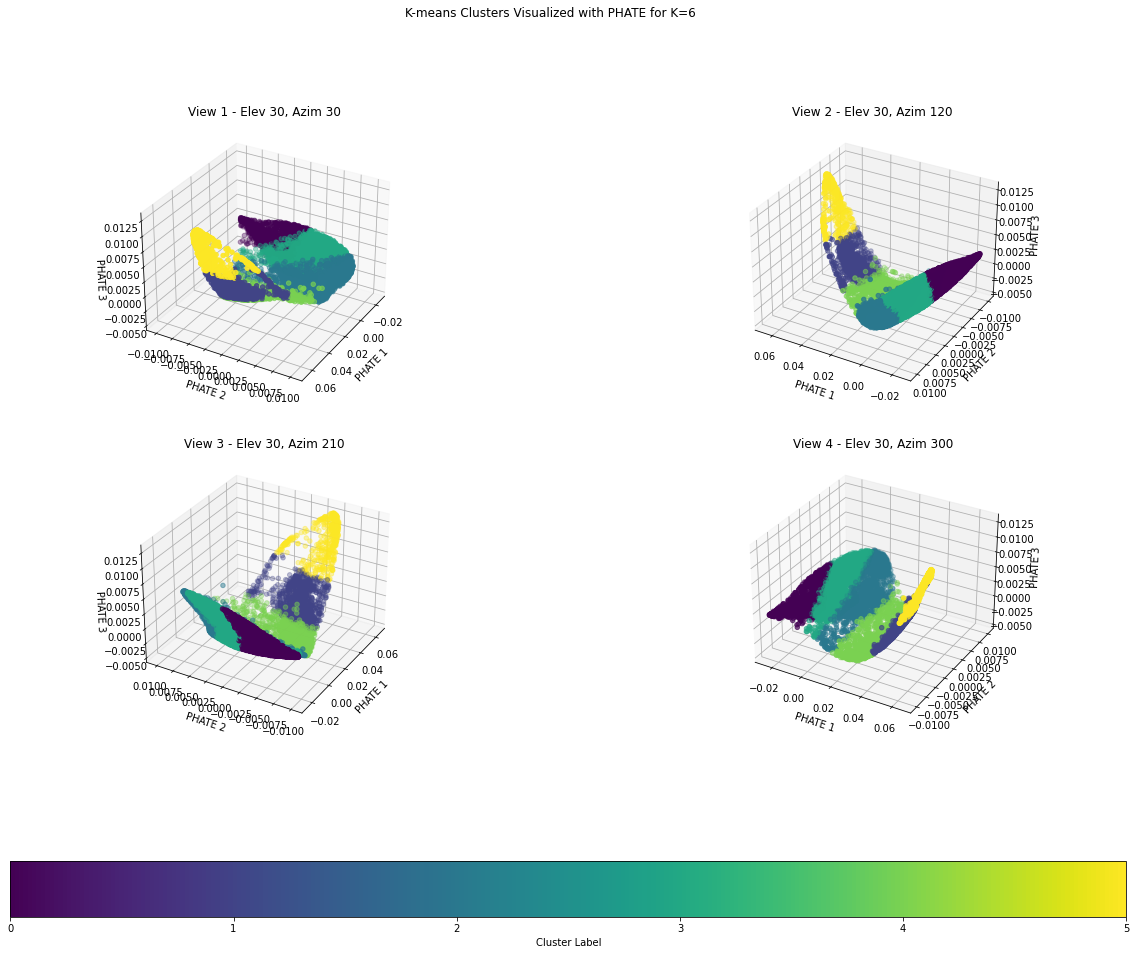

Cluster 0 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    603
5    496
6    493
4    369
3    312
2    204
1    174
Name: sample_ID, dtype: int64

Cluster 1 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    349
2    287
3    225
4    176
5     27
7     25
6     15
Name: sample_ID, dtype: int64

Cluster 2 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    380
5    348
3    296
7    295
4    289
1    279
2    268
Name: sample_ID, dtype: int64

Cluster 3 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    552
6    530
4    495
7    470
3    433
2    412
1    331
Name: sample_ID, dtype: int64

Cluster 4 for K=6 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1   

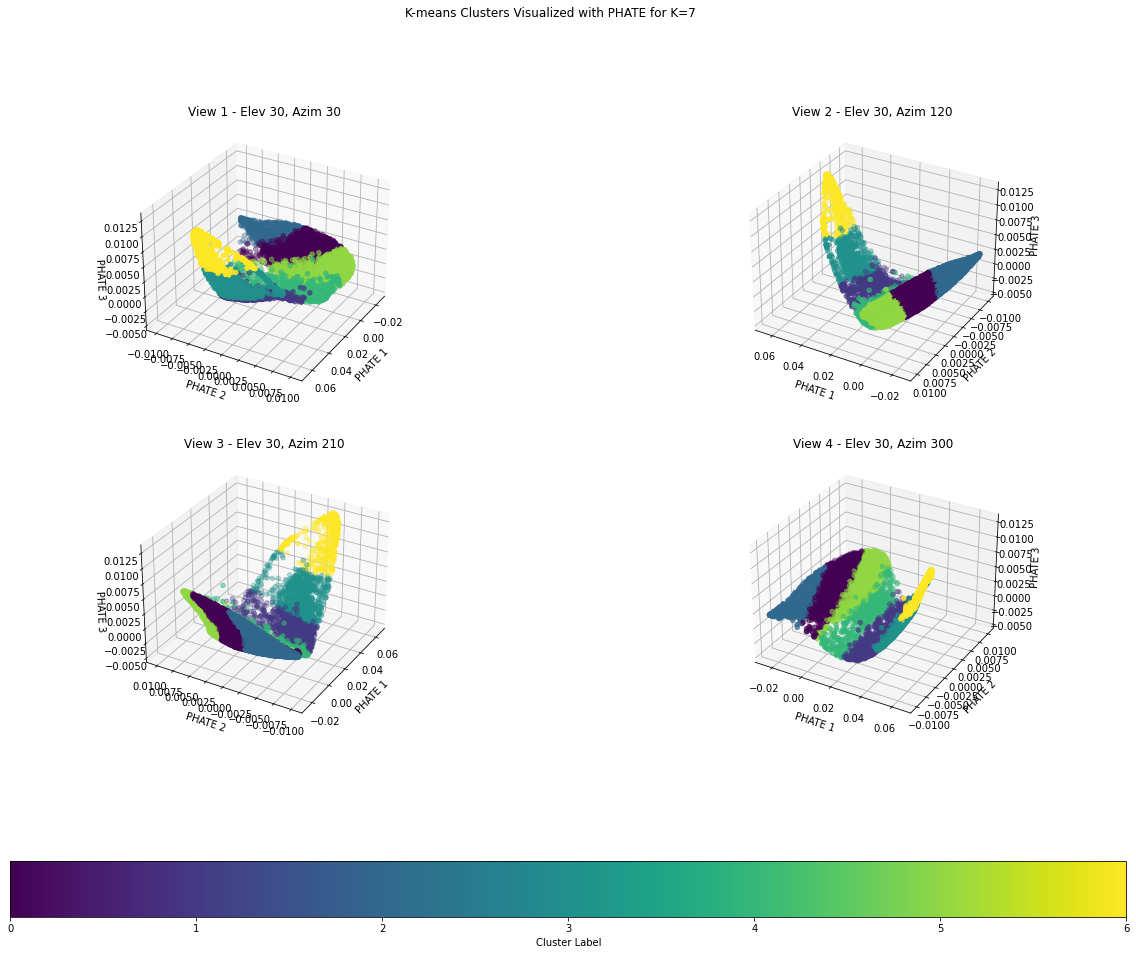

Cluster 0 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    511
5    507
7    459
4    428
3    397
2    358
1    277
Name: sample_ID, dtype: int64

Cluster 1 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    253
2    252
3    179
4    135
5     28
7     19
6     12
Name: sample_ID, dtype: int64

Cluster 2 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    544
5    444
6    430
4    334
3    260
2    170
1    149
Name: sample_ID, dtype: int64

Cluster 3 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    320
2    248
3    211
4    157
5     24
7     23
6     13
Name: sample_ID, dtype: int64

Cluster 4 for K=7 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1   

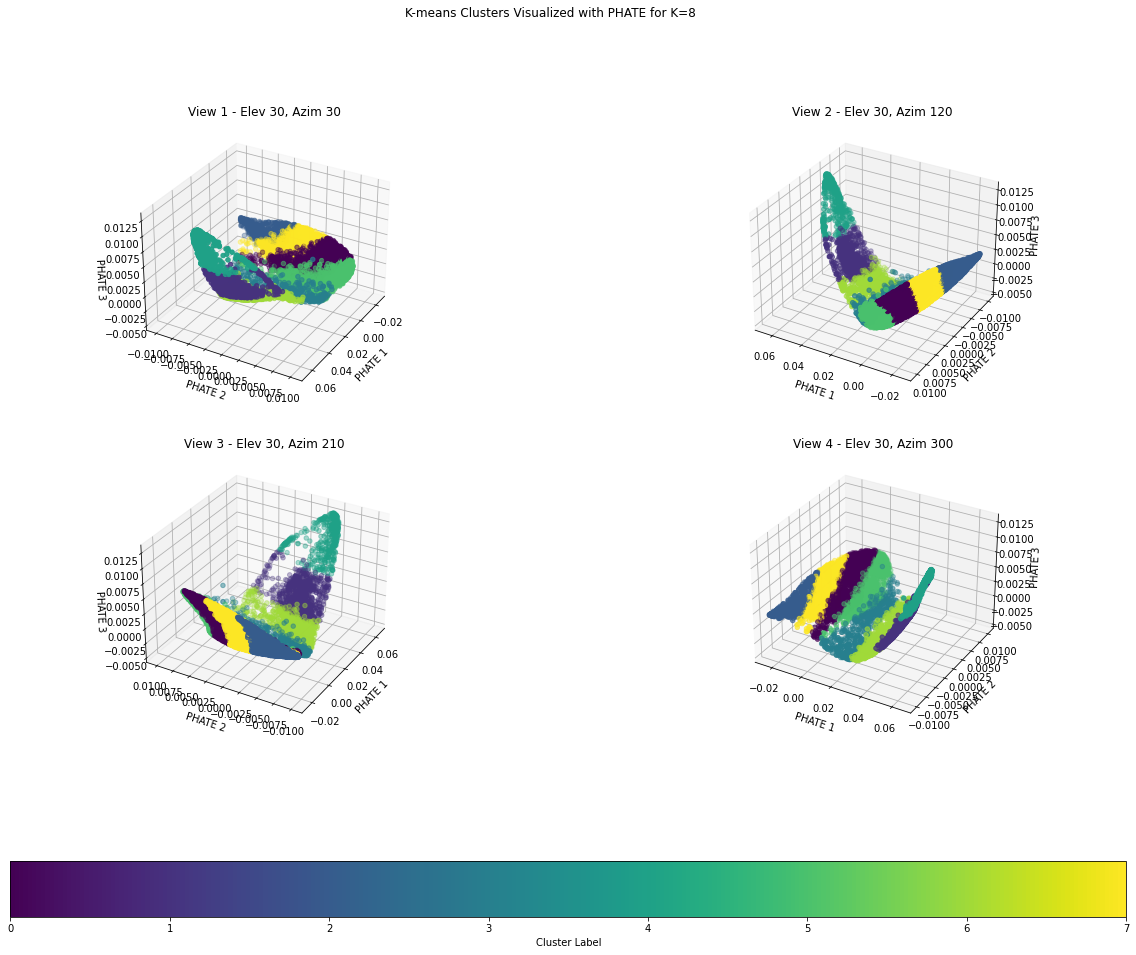

Cluster 0 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    358
6    349
4    321
3    316
2    305
1    285
7    284
Name: sample_ID, dtype: int64

Cluster 1 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    303
2    229
3    191
4    146
5     23
7     20
6     10
Name: sample_ID, dtype: int64

Cluster 2 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    426
5    344
6    334
4    262
3    196
2    117
1    102
Name: sample_ID, dtype: int64

Cluster 3 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    132
2    126
3     90
4     59
6     49
7     40
5     36
Name: sample_ID, dtype: int64

Cluster 4 for K=8 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1   

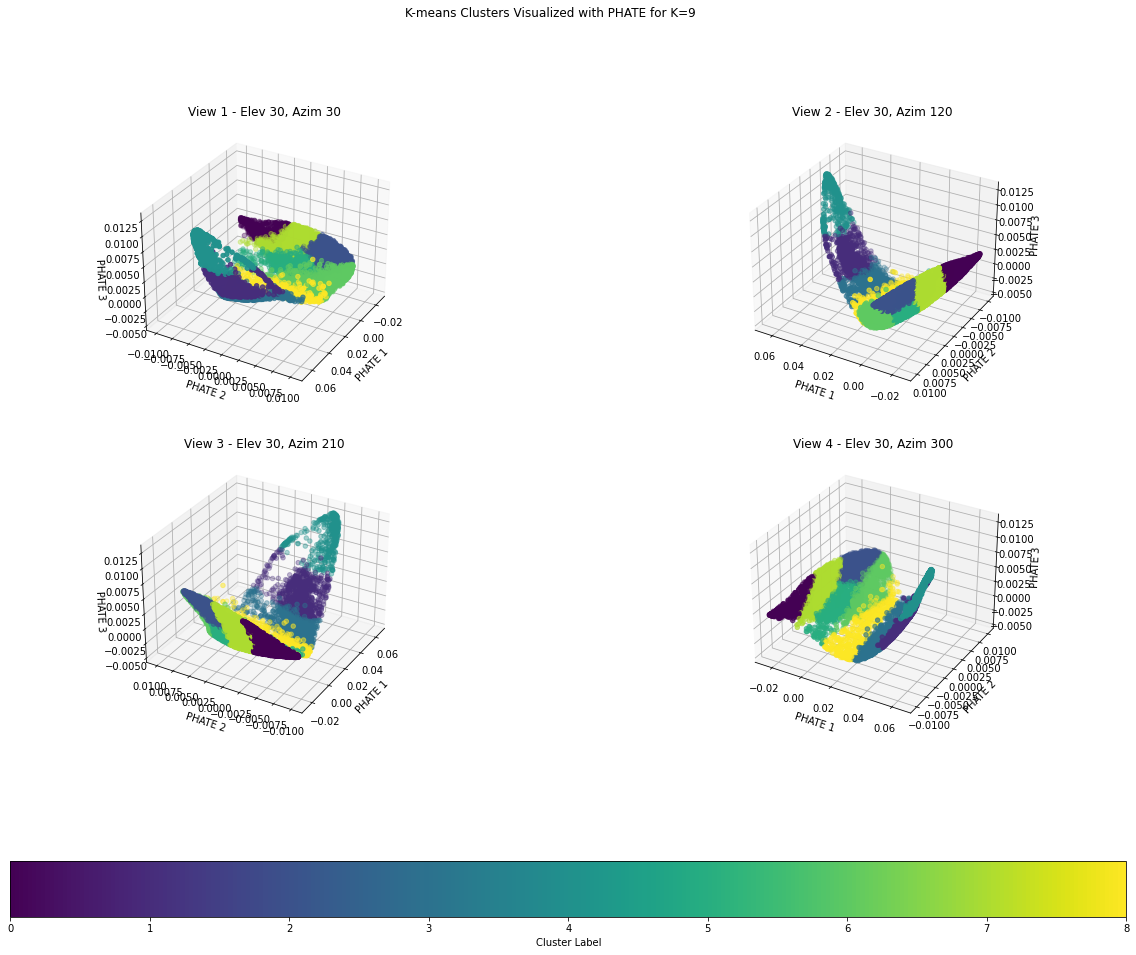

Cluster 0 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    391
5    309
6    304
4    241
3    172
2    104
1     87
Name: sample_ID, dtype: int64

Cluster 1 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    294
2    216
3    186
4    140
5     22
7     19
6      9
Name: sample_ID, dtype: int64

Cluster 2 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
3    229
4    223
2    220
1    196
5    123
6     11
7      1
Name: sample_ID, dtype: int64

Cluster 3 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    241
2    235
3    180
4    131
5     26
7     21
6     13
Name: sample_ID, dtype: int64

Cluster 4 for K=9 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1   

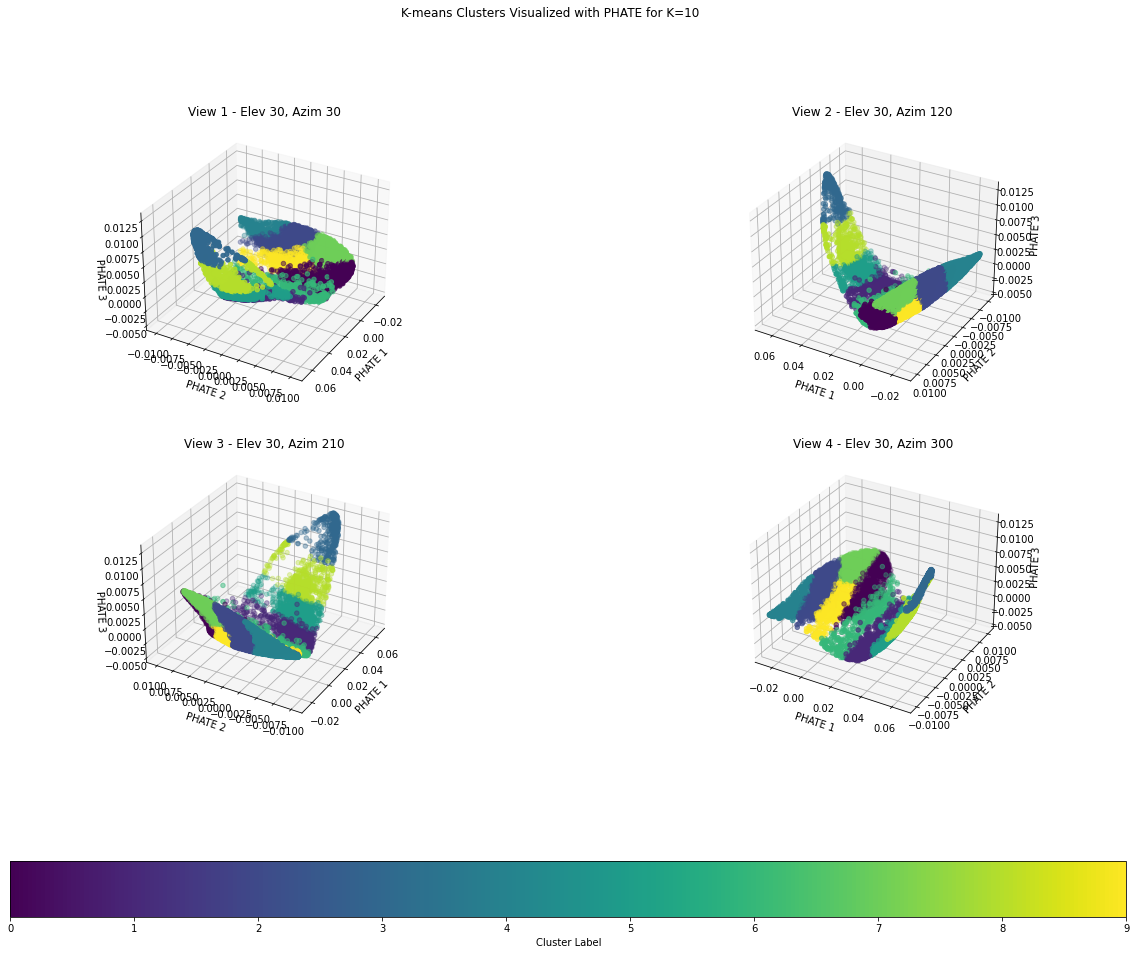

Cluster 0 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    292
5    261
7    222
4    200
3    179
2    164
1    150
Name: sample_ID, dtype: int64

Cluster 1 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
2    195
1    194
3    143
4    102
5     23
7     12
6      8
Name: sample_ID, dtype: int64

Cluster 2 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    390
6    388
7    380
4    304
3    266
2    220
1    159
Name: sample_ID, dtype: int64

Cluster 3 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    66
1    61
2    51
6    49
4    33
3    31
5    29
Name: sample_ID, dtype: int64

Cluster 4 for K=10 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    3

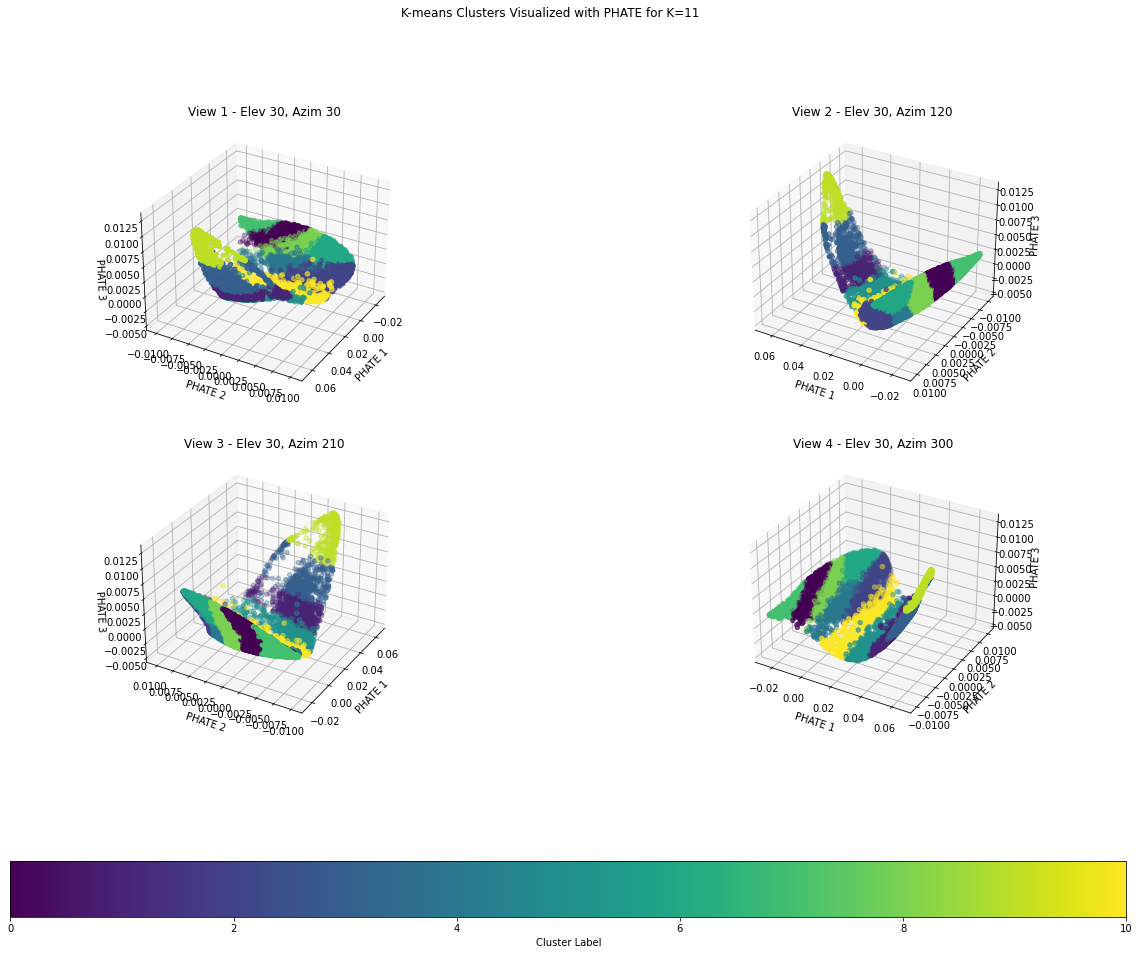

Cluster 0 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    341
6    312
5    284
4    227
3    206
2    142
1    119
Name: sample_ID, dtype: int64

Cluster 1 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    244
2    188
3    153
4    124
5     18
7     18
6     10
Name: sample_ID, dtype: int64

Cluster 2 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    239
5    224
4    173
7    171
2    150
3    150
1    127
Name: sample_ID, dtype: int64

Cluster 3 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    160
2    134
3    109
4     69
7     23
5     21
6     12
Name: sample_ID, dtype: int64

Cluster 4 for K=11 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:

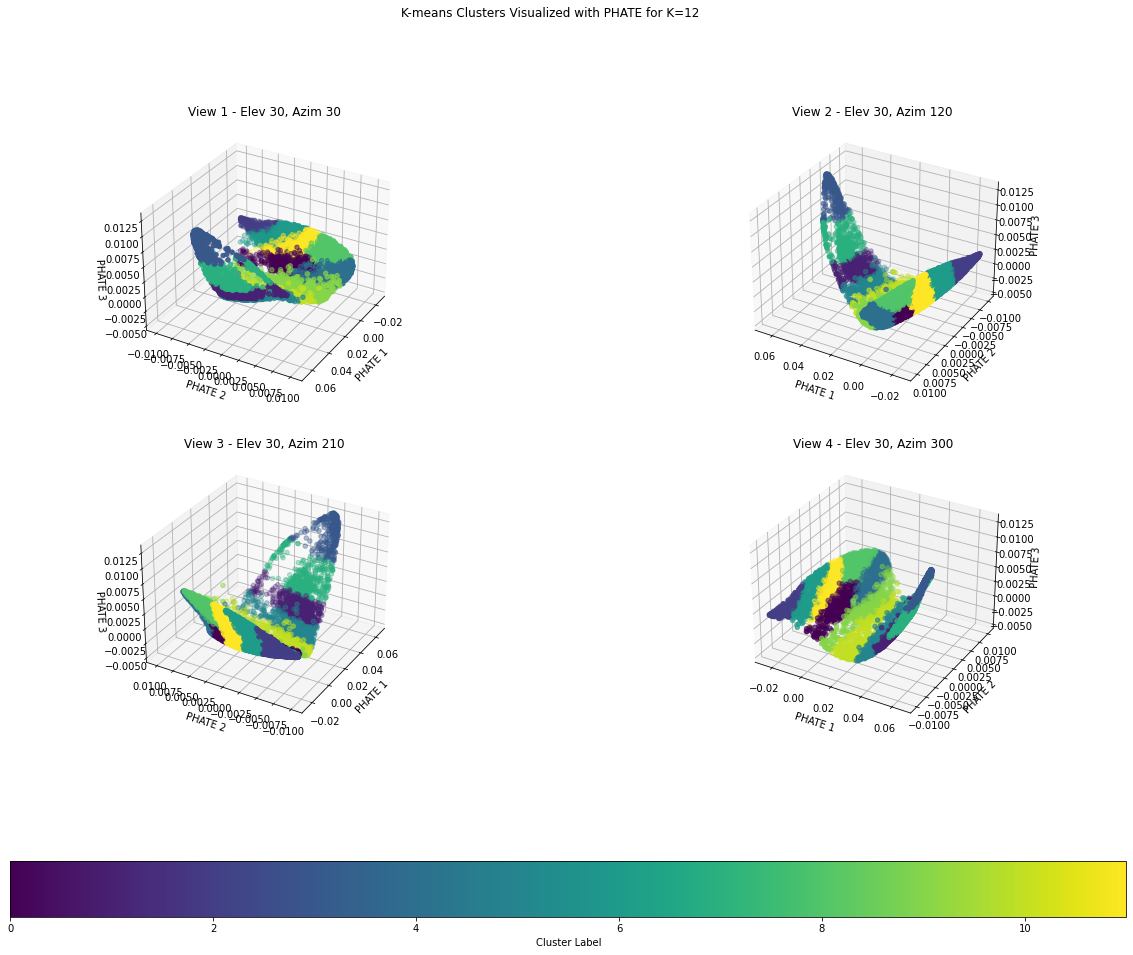

Cluster 0 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
6    322
7    264
5    218
4    143
1    140
3    137
2    110
Name: sample_ID, dtype: int64

Cluster 1 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
1    215
2    176
3    132
4    111
5     15
7     14
6      7
Name: sample_ID, dtype: int64

Cluster 2 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    241
5    197
6    166
4    130
3     99
2     58
1     52
Name: sample_ID, dtype: int64

Cluster 3 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
7    64
1    57
2    49
6    46
4    31
3    29
5    29
Name: sample_ID, dtype: int64

Cluster 4 for K=12 analysis:
Contains unique sample_IDs: [1 2 3 4 5 6 7]
Counts of cells from each sample_ID in the cluster:
5    2

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------- PPTX setup (added) ----------
SAVE_PPTX = True
from pptx import Presentation
from pptx.util import Inches
from PIL import Image  # pip install pillow
import io, os

pptx_dir = r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025\analysis_pipeline_pptx"
os.makedirs(pptx_dir, exist_ok=True)
pptx_path = os.path.join(pptx_dir, "phate_kmeans_views.pptx")

prs = Presentation()
blank_layout = prs.slide_layouts[6]  # blank slide
slide_w, slide_h = prs.slide_width, prs.slide_height
# ----------------------------------------

# Step 1: Retrieve the PHATE embeddings from the AnnData object
embedding = standard_adata_sub.obsm['X_phate']

# Define a list of K values to loop through
k_values = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

for k in k_values:
    # Run K-means clustering for the current value of K using the precomputed PHATE embeddings
    kmeans = KMeans(n_clusters=k, random_state=0).fit(embedding)
    
    # Assign the cluster labels back to the AnnData object
    cluster_label = f'kmeans_clusters_k{k}'
    standard_adata_sub.obs[cluster_label] = kmeans.labels_.astype(str)
    
    # Plotting the clusters for the current value of K using the pre-computed PHATE coordinates
    fig = plt.figure(figsize=(20, 16))
    # Define four views with 90-degree rotations in azimuthal angle
    views = [(30, 30), (30, 120), (30, 210), (30, 300)]
    for i, (elev, azim) in enumerate(views, start=1):
        ax = fig.add_subplot(2, 2, i, projection='3d')
        scatter = ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], c=kmeans.labels_, cmap='viridis')
        ax.view_init(elev=elev, azim=azim)
        ax.set_xlabel('PHATE 1')
        ax.set_ylabel('PHATE 2')
        ax.set_zlabel('PHATE 3')
        ax.set_title(f'View {i} - Elev {elev}, Azim {azim}')
    
    plt.colorbar(scatter, ax=fig.axes, orientation='horizontal', label='Cluster Label')
    plt.suptitle(f'K-means Clusters Visualized with PHATE for K={k}')
    
    # ---------- Add this figure to PPTX (no warping) ----------
    if SAVE_PPTX:
        buf = io.BytesIO()
        dpi_save = 200
        fig.savefig(buf, format="png", dpi=dpi_save, bbox_inches="tight")
        buf.seek(0)

        img = Image.open(buf)
        w_px, h_px = img.size
        w_in, h_in = w_px / dpi_save, h_px / dpi_save
        w_emu, h_emu = Inches(w_in), Inches(h_in)

        # Scale to fit slide while preserving aspect ratio
        scale = min(slide_w / w_emu, slide_h / h_emu)
        new_w, new_h = int(w_emu * scale), int(h_emu * scale)
        left = int((slide_w - new_w) / 2)
        top  = int((slide_h - new_h) / 2)

        slide = prs.slides.add_slide(blank_layout)
        slide.shapes.add_picture(buf, left, top, width=new_w, height=new_h)
    # ----------------------------------------------------------

    plt.show()

    # Report sample_IDs present in each cluster and their counts
    for i in range(k):
        cluster_sample_ids = standard_adata_sub.obs.loc[standard_adata_sub.obs[cluster_label] == str(i), 'sample_ID']
        print(f'Cluster {i} for K={k} analysis:')
        # Reporting unique sample_IDs
        unique_sample_ids = cluster_sample_ids.unique()
        print(f'Contains unique sample_IDs: {unique_sample_ids}')
        # Reporting counts of cells from each sample_ID in the cluster
        sample_id_counts = cluster_sample_ids.value_counts()
        print(f'Counts of cells from each sample_ID in the cluster:\n{sample_id_counts}\n')

# ---------- Save the PPTX after the loop ----------
if SAVE_PPTX:
    prs.save(pptx_path)
    print(f"PHATE K-means PowerPoint saved with {len(prs.slides)} slides:\n{pptx_path}")
# ---------------------------------------------------
